# 2주차 과제: sEMG 전처리 및 DenseNet161 학습

- 이름: 알람
- 학번: 23140912
- GitHub: https://github.com/BK2JJ/semg-auth

## 데이터 처리 안내
공개 저장소의 필터링된 데이터를 사용하였다.
강의 실습에 따라 60Hz 노치 필터와 20~499Hz 대역통과 필터를 추가로 적용하였다.

In [1]:
from pathlib import Path
import numpy as np

files = sorted(Path("data/data").glob("*/*.csv"))

print("CSV files:", len(files))

if files:
    x = np.loadtxt(files[0], delimiter=",", skiprows=1)
    print("Example file:", files[0])
    print("Signal shape:", x.shape)
else:
    print("Check your notebook location and data folder.")

CSV files: 250
Example file: data/data/A/a (1).csv
Signal shape: (3000, 2)


In [4]:
from scipy.signal import iirnotch, butter, filtfilt

FS = 1000

def preprocess(x, fs=FS):
    # Remove 60 Hz electrical noise
    bn, an = iirnotch(60, 30, fs=fs)
    filtered = filtfilt(bn, an, x, axis=0)

    # Keep frequencies between 20 and 499 Hz
    b, a = butter(4, [20, 499], btype="bandpass", fs=fs)
    return filtfilt(b, a, filtered, axis=0)

xf = preprocess(x)

print("Before filtering:", x.shape)
print("After filtering:", xf.shape)
print("Standard deviation before:", x.std())
print("Standard deviation after:", xf.std())

np.save("week2_filtered_example.npy", xf)

Before filtering: (3000, 2)
After filtering: (3000, 2)
Standard deviation before: 0.36156485032189156
Standard deviation after: 0.3582523009409221


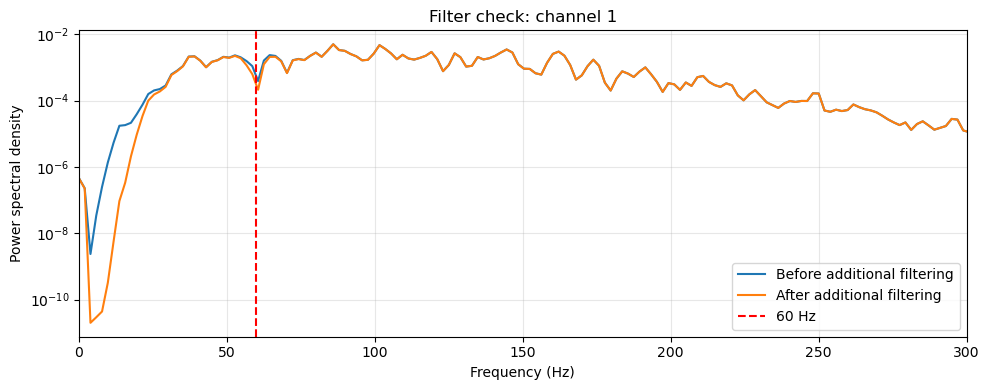

In [6]:
import matplotlib.pyplot as plt
from scipy.signal import welch

# Compare the first channel
f0, p0 = welch(x[:, 0], fs=FS, nperseg=512)
f1, p1 = welch(xf[:, 0], fs=FS, nperseg=512)

plt.figure(figsize=(10, 4))

plt.semilogy(f0, p0, label="Before additional filtering")
plt.semilogy(f1, p1, label="After additional filtering")

plt.axvline(60, color="red", linestyle="--", label="60 Hz")
plt.xlim(0, 300)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("Filter check: channel 1")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("filter_check.png", dpi=150)
plt.show()

In [8]:
WIN = 300
HOP = 150

def make_windows(signal, win=WIN, hop=HOP):
    return np.stack([
        signal[start:start + win]
        for start in range(0, len(signal) - win + 1, hop)
    ])

w = make_windows(xf)

print("Window shape:", w.shape)

np.save("week2_windows_example.npy", w)

Window shape: (19, 300, 2)


In [15]:
def minmax(windows, eps=1e-8):
    minimum = windows.min(axis=(1, 2), keepdims=True)
    maximum = windows.max(axis=(1, 2), keepdims=True)

    return (windows - minimum) / (maximum - minimum + eps)

wn = minmax(w)

print("Shape:", wn.shape)
print("Minimum:", wn.min())
print("Maximum:", wn.max())

np.save("week2_normalized_example.npy", wn)

Shape: (19, 300, 2)
Minimum: 0.0
Maximum: 0.9999999987119951


In [17]:
%pip install PyWavelets

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pywt

SCALES = np.arange(1, 33)

def to_cwt(one_window):
    maps = []

    for ch in range(2):
        coefficients, _ = pywt.cwt(
            one_window[:, ch], SCALES, "morl"
        )
        maps.append(np.abs(coefficients))

    # Third channel: average of the two measured channels
    maps.append((maps[0] + maps[1]) / 2)

    return np.stack(maps).astype(np.float32)

cwt_example = to_cwt(wn[0])

print("CWT shape:", cwt_example.shape)

np.save("week2_cwt_example.npy", cwt_example)

CWT shape: (3, 32, 300)


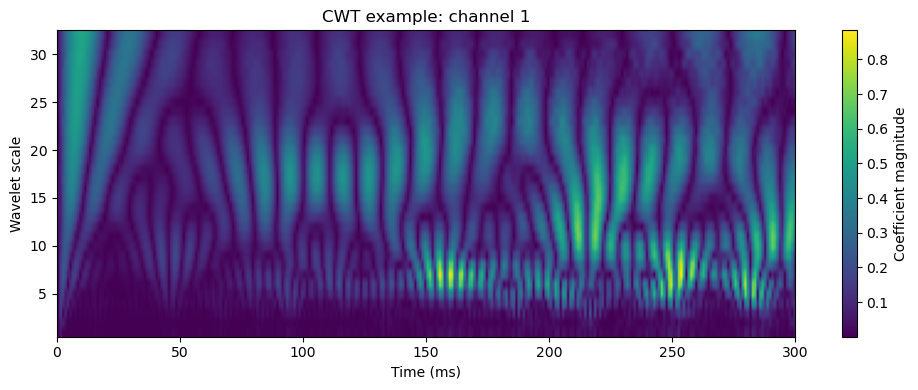

In [22]:
plt.figure(figsize=(10, 4))

plt.imshow(
    cwt_example[0],
    aspect="auto",
    origin="lower",
    extent=[0, 300, 0.5, 32.5],
    cmap="viridis"
)

plt.xlabel("Time (ms)")
plt.ylabel("Wavelet scale")
plt.title("CWT example: channel 1")
plt.colorbar(label="Coefficient magnitude")

plt.tight_layout()
plt.savefig("cwt_example.png", dpi=150)
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Convert subject names into class numbers
subject_names = sorted({f.parent.name for f in files})
label_map = {
    name: number for number, name in enumerate(subject_names)
}

labels = [label_map[f.parent.name] for f in files]

# Split whole trial files first
tr_files, te_files = train_test_split(
    files,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Confirm no file appears in both groups
assert set(tr_files).isdisjoint(te_files)

print("Training trials:", len(tr_files))
print("Test trials:", len(te_files))
print("Shared trials:", len(set(tr_files) & set(te_files)))

# Show and save the split
split_table = pd.DataFrame([
    {"file": str(f), "subject": f.parent.name, "split": split}
    for split, group in [("train", tr_files), ("test", te_files)]
    for f in group
])

split_table.to_csv("week2_trial_split.csv", index=False)

display(pd.crosstab(
    split_table["subject"],
    split_table["split"]
))

Training trials: 200
Test trials: 50
Shared trials: 0


split,test,train
subject,,
A,10,40
B,10,40
C,10,40
D,10,40
E,10,40


In [26]:
def build_dataset(file_list):
    # Each 3-second trial produces 19 windows
    windows_per_trial = 19
    total = len(file_list) * windows_per_trial

    X = np.empty((total, 3, 32, 300), dtype=np.float32)
    y = np.empty(total, dtype=np.int64)

    index = 0

    for trial_number, file in enumerate(file_list, start=1):
        signal = np.loadtxt(file, delimiter=",", skiprows=1)
        assert signal.shape == (3000, 2), f"Unexpected shape: {file}"

        filtered = preprocess(signal)
        windows = minmax(make_windows(filtered))

        for window in windows:
            X[index] = to_cwt(window)
            y[index] = label_map[file.parent.name]
            index += 1

        if trial_number % 25 == 0:
            print(f"Processed {trial_number}/{len(file_list)} trials")

    assert index == total
    assert np.isfinite(X).all()

    return X, y


print("Building training data...")
Xtr, ytr = build_dataset(tr_files)

print("Building test data...")
Xte, yte = build_dataset(te_files)

print("Training shape:", Xtr.shape)
print("Test shape:", Xte.shape)

# Save results so you don't need to repeat the conversion
np.save("week2_Xtr.npy", Xtr)
np.save("week2_ytr.npy", ytr)
np.save("week2_Xte.npy", Xte)
np.save("week2_yte.npy", yte)

Building training data...
Processed 25/200 trials
Processed 50/200 trials
Processed 75/200 trials
Processed 100/200 trials
Processed 125/200 trials
Processed 150/200 trials
Processed 175/200 trials
Processed 200/200 trials
Building test data...
Processed 25/50 trials
Processed 50/50 trials
Training shape: (3800, 3, 32, 300)
Test shape: (950, 3, 32, 300)


In [28]:
summary = pd.DataFrame({
    "Subject": subject_names,
    "Training windows": [
        int(np.sum(ytr == label_map[name]))
        for name in subject_names
    ],
    "Test windows": [
        int(np.sum(yte == label_map[name]))
        for name in subject_names
    ]
})

display(summary)
summary.to_csv("week2_dataset_summary.csv", index=False)

,Subject,Training windows,Test windows
0,A,760,190
1,B,760,190
2,C,760,190
3,D,760,190
4,E,760,190


In [30]:
%pip install torch torchvision

  Using cached torch-2.14.0-cp312-cp312-macosx_14_0_arm64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp312-cp312-macosx_14_0_arm64.whl.metadata (5.7 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached torch-2.14.0-cp312-cp312-macosx_14_0_arm64.whl (127.3 MB)
Using cached torchvision-0.29.0-cp312-cp312-macosx_14_0_arm64.whl (1.8 MB)
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.12
    Uninstalling sympy-1.12:
      Successfully uninstalled sympy-1.12
  Attempting uninstall: setuptools
    Found existing installation: setuptools 69.5.1
    Uninstalling setuptools-69.5.1:
      Successfully uninstalled setuptools-69.5.1
Note: you may need to restart the kernel to use updated packages.


In [32]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import densenet161

torch.manual_seed(42)

# Use an available GPU, including supported Mac GPUs
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# Prepare batches of 16 training windows
train_dataset = TensorDataset(
    torch.from_numpy(Xtr),
    torch.from_numpy(ytr)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

# Create DenseNet161 without pretrained weights
model = densenet161(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 5)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Check one batch without training
xb, yb = next(iter(train_loader))

model.eval()
with torch.no_grad():
    output = model(xb.to(device))

print("Input shape:", xb.shape)
print("Output shape:", output.shape)
print("Outputs are finite:", torch.isfinite(output).all().item())

model.train()

Device: mps
Input shape: torch.Size([16, 3, 32, 300])
Output shape: torch.Size([16, 5])
Outputs are finite: True


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, bias=

In [34]:
import time
import pandas as pd

EPOCHS = 5
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    start = time.perf_counter()
    total_loss = 0.0
    total_samples = 0

    for batch_number, (xb, yb) in enumerate(train_loader, start=1):
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = model(xb)
        loss = criterion(predictions, yb)

        if not torch.isfinite(loss).item():
            raise RuntimeError("Loss became NaN or infinite.")

        loss.backward()
        optimizer.step()

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        if batch_number == 1 or batch_number % 50 == 0:
            print(
                f"Epoch {epoch}/{EPOCHS} | "
                f"Batch {batch_number}/{len(train_loader)}",
                flush=True
            )

    average_loss = total_loss / total_samples
    elapsed = time.perf_counter() - start

    history.append({
        "epoch": epoch,
        "train_loss": average_loss,
        "seconds": elapsed
    })

    print(
        f"Epoch {epoch}/{EPOCHS} finished | "
        f"Loss: {average_loss:.4f} | "
        f"Time: {elapsed:.1f} seconds",
        flush=True
    )

    # Save the log and latest checkpoint after every epoch
    pd.DataFrame(history).to_csv(
        "week2_training_log.csv", index=False
    )

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "label_map": label_map,
        "history": history
    }, "week2_checkpoint.pth")

print("Training finished!")
display(pd.DataFrame(history))

Epoch 1/5 | Batch 1/238
Epoch 1/5 | Batch 50/238
Epoch 1/5 | Batch 100/238
Epoch 1/5 | Batch 150/238
Epoch 1/5 | Batch 200/238
Epoch 1/5 finished | Loss: 1.0125 | Time: 100.2 seconds
Epoch 2/5 | Batch 1/238
Epoch 2/5 | Batch 50/238
Epoch 2/5 | Batch 100/238
Epoch 2/5 | Batch 150/238
Epoch 2/5 | Batch 200/238
Epoch 2/5 finished | Loss: 0.6915 | Time: 86.7 seconds
Epoch 3/5 | Batch 1/238
Epoch 3/5 | Batch 50/238
Epoch 3/5 | Batch 100/238
Epoch 3/5 | Batch 150/238
Epoch 3/5 | Batch 200/238
Epoch 3/5 finished | Loss: 0.5783 | Time: 86.6 seconds
Epoch 4/5 | Batch 1/238
Epoch 4/5 | Batch 50/238
Epoch 4/5 | Batch 100/238
Epoch 4/5 | Batch 150/238
Epoch 4/5 | Batch 200/238
Epoch 4/5 finished | Loss: 0.5217 | Time: 86.7 seconds
Epoch 5/5 | Batch 1/238
Epoch 5/5 | Batch 50/238
Epoch 5/5 | Batch 100/238
Epoch 5/5 | Batch 150/238
Epoch 5/5 | Batch 200/238
Epoch 5/5 finished | Loss: 0.4459 | Time: 86.7 seconds
Training finished!


,epoch,train_loss,seconds
0,1,1.012488,100.195110
1,2,0.691491,86.676037
2,3,0.578344,86.604626
3,4,0.521729,86.659568
4,5,0.445944,86.654913


## 설정 근거

### 윈도우 길이: 300ms
300ms는 근전도 신호의 짧은 변화와 개인별 특징을 담을 수 있는 길이이다.
3초 신호를 50% 겹치게 나누면 시행당 19개의 윈도우를 만들 수 있다.

### CWT 스케일 수: 32
32개 스케일을 사용하면 여러 주파수 대역의 신호 변화를 살펴볼 수 있다.
이번 실습에서는 신호의 특징과 계산량을 함께 고려하여 강의에서 제시한 32개를 사용하였다.

## 학습 결과
5에폭 동안 학습 손실이 1.0125에서 0.4459로 감소하였다.
학습 데이터에 대한 예측이 개선되었으며, 새로운 데이터에 대한 성능은 테스트 데이터로 따로 확인해야 한다.